# **Logistic Regression for Credit Risk Assessment**

### **Objective**
The objective of this project is to build an end-to-end binary classification pipeline using Logistic Regression to predict loan default status (`loan_status`) based on borrower credit features. This framework explores data exploration, feature selection, train-test splitting, and performance evaluation metrics to analyze how class imbalances impact real-world credit models and how model recall can be optimized for risk mitigation.


## Dataset

- File: `credit_risk_dataset.csv`  
- Target: `loan_status` (e.g., 1 = default, 0 = fully paid).  


## 1. Imports

In [ ]:

# TODO: Import libraries
# Rules: use matplotlib (no seaborn), one chart per plot, don't set colors explicitly.
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)


## 2. Load Data

In [ ]:
df = pd.read_csv("credit_risk_dataset.csv")

print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Inspect & Clean

In [ ]:
# Check data types and missing values
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

# Drop rows with missing values
df = df.dropna()
print("\nShape after dropping NaNs:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None

Missing values:
 person_a

## 4. Choose 4 Features (X) and Target (Y)

In [ ]:
# These 5 features have strong links to default risk
chosen_features = [
    "loan_percent_income",       # debt burden relative to income
    "loan_int_rate",             # riskier borrowers get higher rates
    "person_emp_length",         # longer employment = stable income
    "loan_amnt",                 # larger loans harder to repay
    "cb_person_cred_hist_length" # longer history = more established borrower
]

target_col = "loan_status"

X = df[chosen_features]
y = df[target_col]

print("X shape:", X.shape)
print("Class balance:\n", y.value_counts(normalize=True))

X shape: (28638, 5)
Class balance:
 loan_status
0    0.7834
1    0.2166
Name: proportion, dtype: float64


## 5. Preprocess & Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

# Scale features so coefficients are comparable
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same scale to test

Train: (20046, 5)  Test: (8592, 5)


## 6. Fit Logistic Regression

In [ ]:

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


## 7. Evaluate

Accuracy: 0.8324
ROC-AUC : 0.8355

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90      6731
           1       0.69      0.40      0.51      1861

    accuracy                           0.83      8592
   macro avg       0.77      0.68      0.70      8592
weighted avg       0.82      0.83      0.81      8592



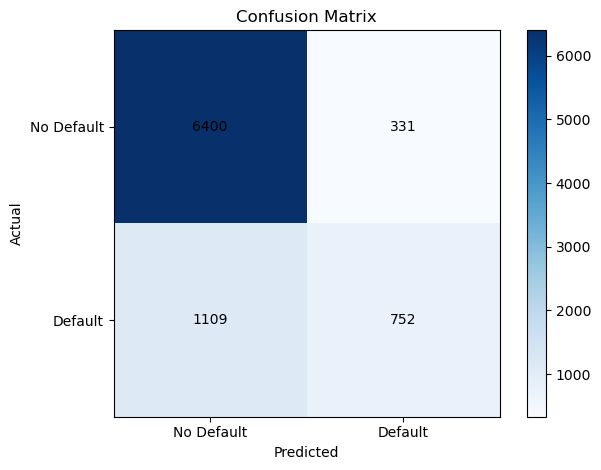

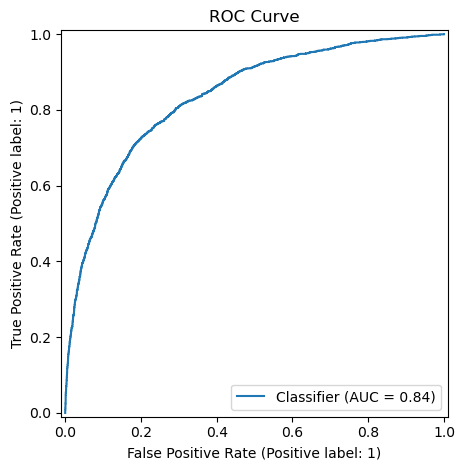

In [ ]:

y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Accuracy and AUC
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Default", "Default"])
plt.yticks([0, 1], ["No Default", "Default"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

## 8. Coefficients / Feature Effects

                   Feature  Coefficient
                 loan_amnt    -0.577242
         person_emp_length    -0.106493
cb_person_cred_hist_length     0.013694
             loan_int_rate     1.006104
       loan_percent_income     1.266932


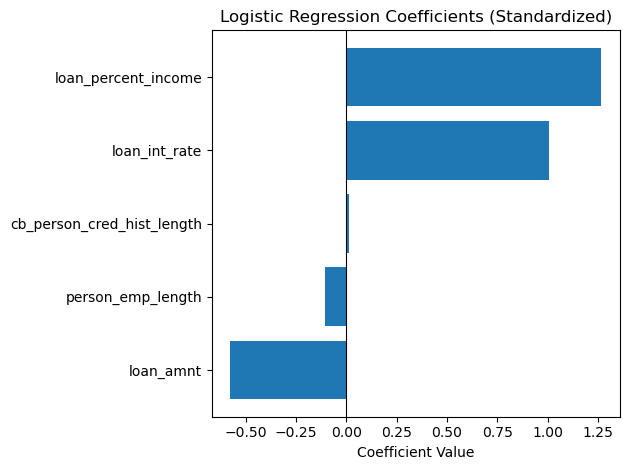

In [ ]:

coef_df = pd.DataFrame({
    "Feature": chosen_features,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient")

print(coef_df.to_string(index=False))

# Bar chart
plt.figure()
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients (Standardized)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

## 9. Interpretation

### Positive Coefficients (increase default probability)
- **loan_percent_income** (1.27): Strongest predictor. Borrowers whose loan
  payment is a large share of their income are much more likely to default.
- **loan_int_rate** (1.01): Second strongest. Higher rates are assigned to
  riskier borrowers, confirming it is a strong default signal.
- **cb_person_cred_hist_length** (0.01): Near-zero effect — not meaningful.

### Negative Coefficients (decrease default probability)
- **loan_amnt** (-0.58): Larger loans slightly reduce predicted default risk,
  possibly because larger loans go to more creditworthy borrowers.
- **person_emp_length** (-0.11): Longer employment reduces default risk,
  consistent with greater income stability.

### Model Quality
- **Accuracy: 83.24%** — correctly classifies 83% of borrowers.
- **ROC-AUC: 0.84** — strong ability to distinguish defaulters from non-defaulters.
- **Recall for defaulters (class 1): only 40%** — the model misses 1,109 out
  of 1,861 actual defaults. This is the key weakness.

### Limitation
The dataset is **class-imbalanced** (many more non-defaults than defaults).
The model is biased toward predicting "No Default," which inflates accuracy
but causes it to miss most actual defaulters — risky in a real lending context.

### Suggested Improvement
Add `class_weight="balanced"` to `LogisticRegression()` to penalize missed
defaults more heavily, improving recall on defaulters at a small cost to
overall accuracy.